In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# parameters
h = 7
w = 10
states = [(x, y) for x in range(w) for y in range(h)]
windStrength = [0, 0, 0, 1, 1, 1, 2, 2, 1, 0]
epsilon = 0.1
alpha = 0.5
actions = [(1, 0), (0, 1), (-1, 0), (0, -1)]
start = (0, 3)
goal = (7, 3)
T = 500

In [3]:
def decideAction(Q, state, epsilon):
    sample = np.random.random()
    if sample < epsilon:
        # random
        return actions[np.random.choice([num for num in range(4)])]
    else:
        # greedy
        maxQ = -1e6
        for action in actions:
            if Q[state][action] > maxQ:
                maxQ = Q[state][action]
                optimalAction = action
        return optimalAction

In [4]:
def takeAction(state, action):
    x, y = state
    dx, dy = action
    nx = x + dx
    nx = min(max(nx, 0), w - 1)
    ny = y + dy + windStrength[x]
    ny = min(max(ny, 0), h - 1)
    return (nx, ny)

In [5]:
Q = {state : {action : 0 for action in actions} for state in states}
# policy = {state : {action : 1 / 4 for action in actions} for state in states}
for t in range(T):
    currState = start
    currAction = decideAction(Q, currState, epsilon / (t + 1))
    while currState != goal:
        nextState = takeAction(currState, currAction)
        reward = -1
        nextAction = decideAction(Q, nextState, epsilon / (t + 1))
        Q[currState][currAction] = Q[currState][currAction] + alpha * (reward + Q[nextState][nextAction] - Q[currState][currAction])
        currState = nextState
        currAction = nextAction

In [6]:
policy = {}
for state in states:
    maxQ = -1e6
    optimalAction = None
    for action in actions:
        if Q[state][action] > maxQ:
            maxQ = Q[state][action]
            optimalAction = action
    policy[state] = optimalAction

In [7]:
state = start
count = 0
path = []
while state != goal:
    path.append(state)
    action = policy[state]
    state = takeAction(state, action)
    count += 1
path.append(goal)
print(count)

15


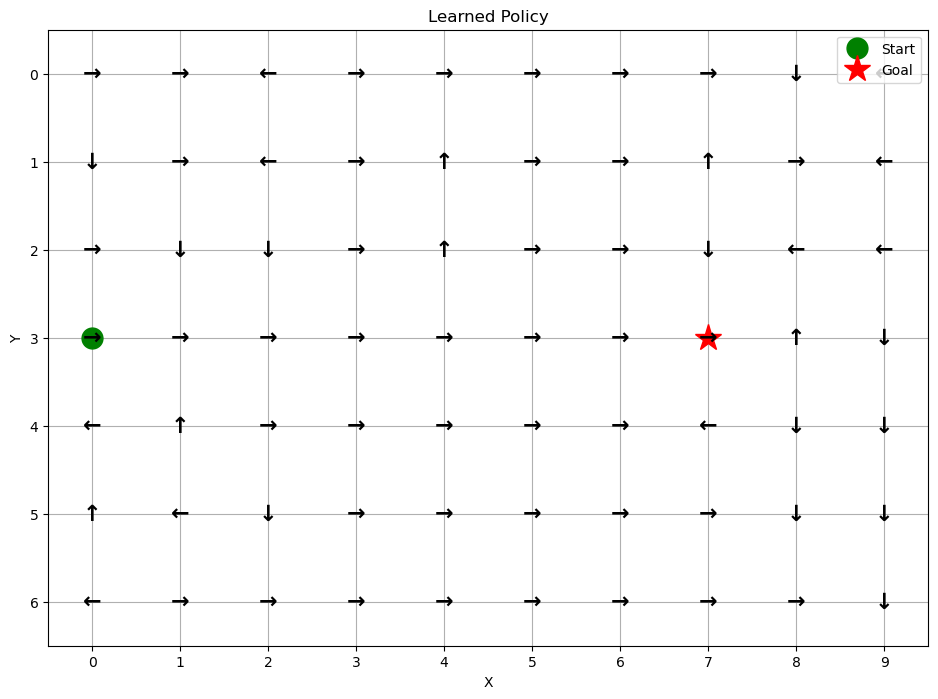

In [8]:
def showPolicy(policy):
    # Create a grid to visualize the policy
    grid = np.zeros((h, w), dtype=object)
    
    # Arrow mapping for actions
    arrows = {
        (1, 0): '→',   # right
        (0, 1): '↑',   # up
        (-1, 0): '←',  # left
        (0, -1): '↓'   # down
    }
    
    # Fill grid with policy arrows
    for state in states:
        x, y = state
        action = policy[state]
        grid[y, x] = arrows[action]
    
    # Plot
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.set_xlim(-0.5, w - 0.5)
    ax.set_ylim(-0.5, h - 0.5)
    ax.set_aspect('equal')
    ax.invert_yaxis()
    ax.set_xticks(range(w))
    ax.set_yticks(range(h))
    ax.grid(True)
    
    # Draw arrows on grid
    for state in states:
        x, y = state
        ax.text(x, y, grid[y, x], ha='center', va='center', fontsize=16, fontweight='bold')
    
    # Mark start and goal
    ax.plot(start[0], start[1], 'go', markersize=15, label='Start')
    ax.plot(goal[0], goal[1], 'r*', markersize=20, label='Goal')
    
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title('Learned Policy')
    ax.legend()
    plt.show()

showPolicy(policy)

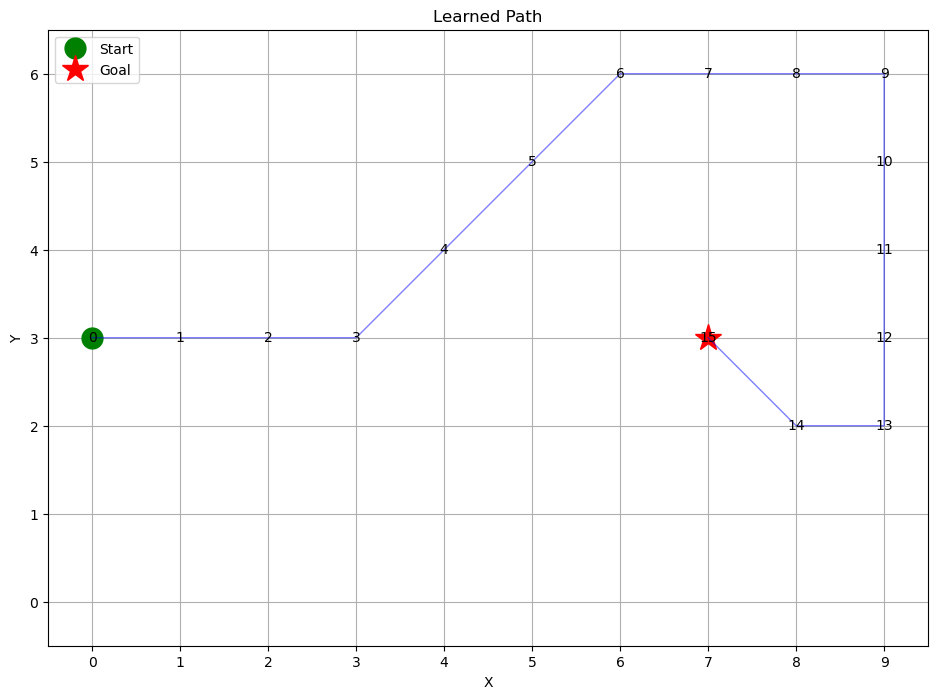

In [9]:
def showPath(path):
    # Create a grid to visualize the path
    grid = np.zeros((h, w), dtype=int)
    
    # Mark the path
    for i, state in enumerate(path):
        x, y = state
        grid[y, x] = i
    
    # Plot
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.set_xlim(-0.5, w - 0.5)
    ax.set_ylim(-0.5, h - 0.5)
    ax.set_aspect('equal')
    ax.set_xticks(range(w))
    ax.set_yticks(range(h))
    ax.grid(True)
    
    # Draw path on grid
    for i, state in enumerate(path):
        x, y = state
        ax.text(x, y, str(i), ha='center', va='center', fontsize=10)
    
    # Mark start and goal
    ax.plot(start[0], start[1], 'go', markersize=15, label='Start')
    ax.plot(goal[0], goal[1], 'r*', markersize=20, label='Goal')
    
    # Draw line connecting the path
    xs = [state[0] for state in path]
    ys = [state[1] for state in path]
    ax.plot(xs, ys, 'b-', alpha=0.5, linewidth=1)
    
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title('Learned Path')
    ax.legend()
    plt.show()

showPath(path)